In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

m (coef)    = 6.0970
b (intercept) = 29.4667
MSE = 1.1224
R²  = 0.9964


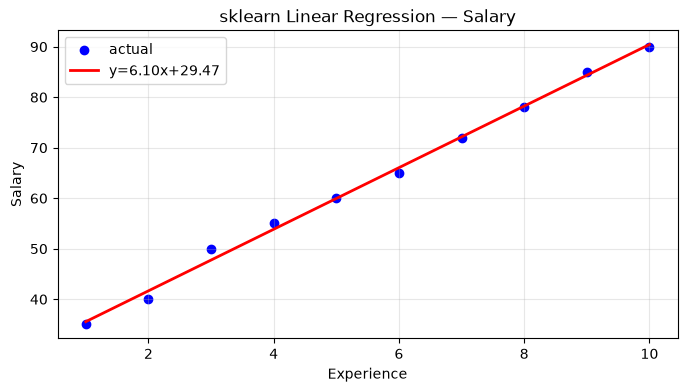

In [2]:

X = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float).reshape(-1,1)
y = np.array([35,40,50,55,60,65,72,78,85,90], dtype=float)

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)
r2  = r2_score(y, y_pred)

print(f"m (coef)    = {model.coef_[0]:.4f}")
print(f"b (intercept) = {model.intercept_:.4f}")
print(f"MSE = {mse:.4f}")
print(f"R²  = {r2:.4f}")   # 1.0 = perfect fit

plt.figure(figsize=(8, 4))
plt.scatter(X, y, color='blue', label='actual')
plt.plot(X, y_pred, 'r-', linewidth=2,
         label=f'y={model.coef_[0]:.2f}x+{model.intercept_:.2f}')
plt.xlabel('Experience'); plt.ylabel('Salary')
plt.title('sklearn Linear Regression — Salary'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

Train R² = 0.9098
Test  R² = 0.9325
Test MSE = 9.9527


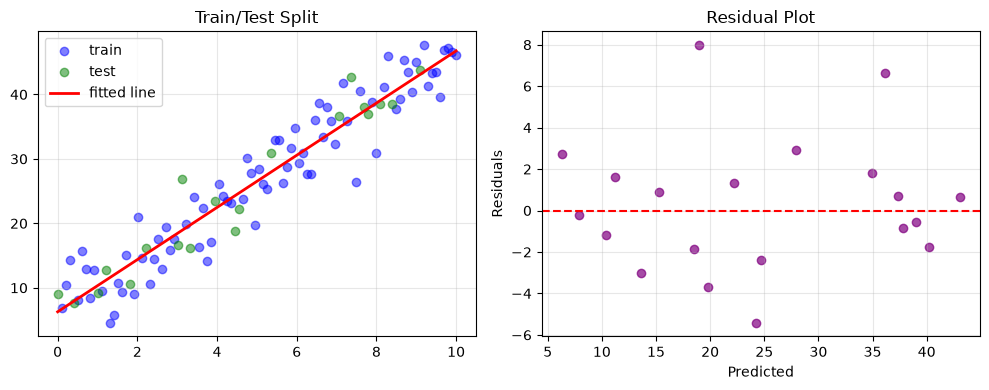

In [3]:
# Cell 3 — Version 2: train/test split + residual plot
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 4*X.flatten() + 7 + np.random.randn(100) * 4

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

print(f"Train R² = {r2_score(y_train, y_pred_train):.4f}")
print(f"Test  R² = {r2_score(y_test,  y_pred_test):.4f}")
print(f"Test MSE = {mean_squared_error(y_test, y_pred_test):.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.scatter(X_train, y_train, color='blue',  alpha=0.5, label='train')
plt.scatter(X_test,  y_test,  color='green', alpha=0.5, label='test')
plt.plot(X, model.predict(X), 'r-', linewidth=2, label='fitted line')
plt.title('Train/Test Split'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, color='purple', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted'); plt.ylabel('Residuals')
plt.title('Residual Plot')   # random scatter = good fit ✅
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

m  = 0.0767
b  = -2.2950
R² = 0.9994
Predicted price for 1600 sqft: 120.40 lakhs


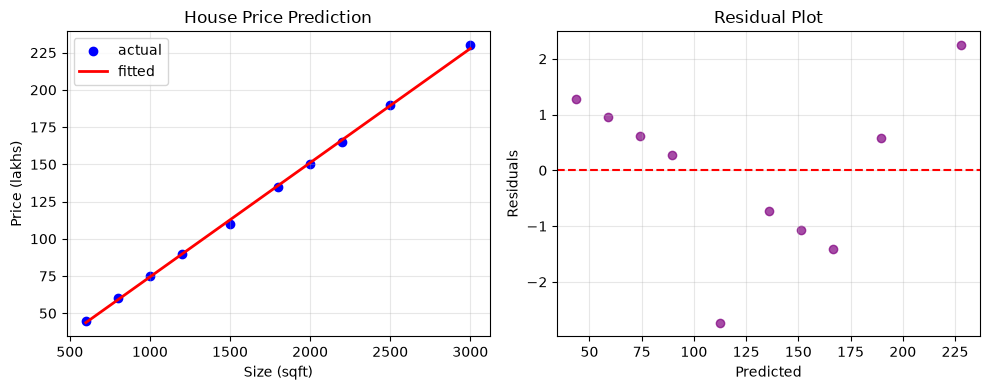

In [4]:
# Cell 4 — Version 3: house size vs price
X = np.array([600,800,1000,1200,1500,1800,2000,2200,2500,3000],
             dtype=float).reshape(-1,1)
y = np.array([45,60,75,90,110,135,150,165,190,230], dtype=float)

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f"m  = {model.coef_[0]:.4f}")
print(f"b  = {model.intercept_:.4f}")
print(f"R² = {r2_score(y, y_pred):.4f}")
print(f"Predicted price for 1600 sqft: {model.predict([[1600]])[0]:.2f} lakhs")

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.scatter(X, y, color='blue', label='actual')
plt.plot(X, y_pred, 'r-', linewidth=2, label='fitted')
plt.xlabel('Size (sqft)'); plt.ylabel('Price (lakhs)')
plt.title('House Price Prediction'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
residuals = y - y_pred
plt.scatter(y_pred, residuals, color='purple', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted'); plt.ylabel('Residuals')
plt.title('Residual Plot'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

         m (slope)    b (intercept)
Scratch: 7.2382        21.5217
sklearn: 6.0970        29.4667


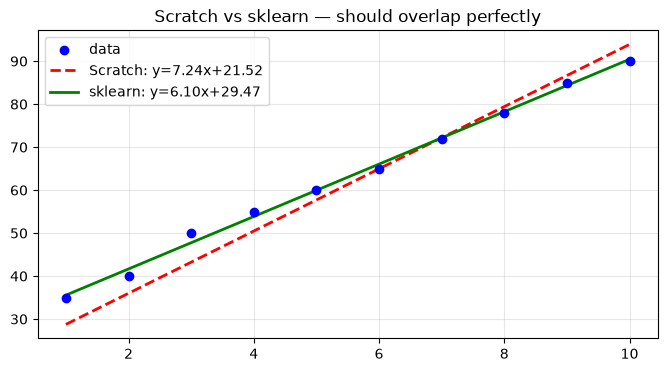

In [5]:
# Cell 5 — Version 4: compare scratch vs sklearn side by side
X_raw = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float)
y     = np.array([35,40,50,55,60,65,72,78,85,90], dtype=float)

# ── scratch ──────────────────────────────
m, b = 0.0, 0.0
lr = 0.001
for _ in range(3000):
    y_pred = m * X_raw + b
    dm = (2/len(X_raw)) * np.sum((y_pred - y) * X_raw)
    db = (2/len(X_raw)) * np.sum((y_pred - y))
    m -= lr * dm; b -= lr * db

# ── sklearn ───────────────────────────────
from sklearn.linear_model import LinearRegression
sk_model = LinearRegression()
sk_model.fit(X_raw.reshape(-1,1), y)

print("         m (slope)    b (intercept)")
print(f"Scratch: {m:.4f}        {b:.4f}")
print(f"sklearn: {sk_model.coef_[0]:.4f}        {sk_model.intercept_:.4f}")
# both should be nearly identical ✅

plt.figure(figsize=(8, 4))
plt.scatter(X_raw, y, color='blue', label='data', zorder=5)
plt.plot(X_raw, m*X_raw + b,
         'r--', linewidth=2, label=f'Scratch: y={m:.2f}x+{b:.2f}')
plt.plot(X_raw, sk_model.predict(X_raw.reshape(-1,1)),
         'g-',  linewidth=2, label=f'sklearn: y={sk_model.coef_[0]:.2f}x+{sk_model.intercept_:.2f}')
plt.title('Scratch vs sklearn — should overlap perfectly')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()